# Programming Tutorial 2: Model Training and Evaluation

```
Course: CSCI 4922/5922 Spring 2026, University of Colorado Boulder
TA: Everley Tseng
Email: Yu-Yun.Tseng@colorado.edu
* AI assistant was used in making this tutorial
```


## Overview

Sections:
- Introduction to PyTorch built-in tools
- Train a binary classification model
  1. Prepare a dataset
  2. Build an architecture
  3. Train the model
  4. Evaluate the model

Objectives:
- Learn how to utilize the PyTorch built-in tools
- Learn the steps toward building and training a model
- Learn how to visualize the training process and evaluate the results
- Learn how to visualize the model architecture

## I. PyTorch Built-ins

### What's Beyond Tensors Operations?

Training neural networks involves lots of multi-dimensional arrays, which can be represented by tensors like those we practiced with in Programming Tutorial 1. Some examples of tensor usages include:
- **Data Representation**: Tensors are used to represent inputs (e.g., images, text, audio) and outputs for the models.
Example: An image can be represented as a 3D tensor with dimensions [channels, height, width].
- **Model Parameters**: Neural network weights and biases are stored as tensors.
- **Intermediate Calculations**: During forward and backward passes, tensors store intermediate results and gradients.

The `torch` library simplifies working with these tensors. In fact, beyond the tensor operations in the first tutorial, there are a variety of **built-in** modules wrapped around the tensors for building neural networks. In this section, we will explore the basic components of neural network models and their corresponding built-in tools in `torch`.


Most of the model components are available in `torch.nn`. For efficiency, we often start with the following imports:

In [1]:
import torch
import torch.nn as nn

### Layers


- **Feedforward Layer**:

  Today, we'll be using the linear layer, [`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html). This `nn.Linear` resembles the operation we implemented in Programming Tutorial 1. The built-in function is able to initialize the parameters (e.g., weights and biases) randomly and their default mode is `requires_grad=True`.

  Use the [index](https://docs.pytorch.org/docs/stable/nn.html) in `torch.nn` to see what other layers are available in PyTorch.

- **Activation Layer**:

  Today, we'll be using *sigmoid*, [`nn.Sigmoid()`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html).

  Explore the [non-linear activation functions](https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity) available in `torch.nn`.

### Model

- **Neural Network Module**:

  [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) is the base class for all neural network modules. This is where you define the structure of your neural network, including its layers and how data flows through them.

### Training

- **Optimizer**:

  Today, we'll be using the [SGD optimizer](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD). It requires the input of the model parameters (`params`), and lets users override default values such as the learning rate `lr` (e.g., `lr=0.001`).

  The optimizers are responsible for updating the model parameters based on the gradients calculated during training. Choose one from the [optimizers index](https://pytorch.org/docs/stable/optim.html#algorithms) and review the documentation for how to use the chosen optimizer.

  What is `optimizer.zero_grad()`?  [link](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html)

- **Loss function**:

  For a binary classification task, it is common to use the [**Binary Cross Entropy Loss**](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html).

  The loss function measures the error (i.e., difference between the model's predictions and the actual target values). During training, the optimizer works to **minimize this error**. Check out the available loss functions in the [loss functions index](https://pytorch.org/docs/stable/nn.html#loss-functions).

### Evaluation

- **Metric**:

  In today's practice, we will use the metric, **accuracy**, to evaluate a binary classification model. The tool, [`torchmetrics.classification.BinaryAccuracy`](https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html#binaryaccuracy) requires installation of the library, `torchmetrics`.

  Evaluation metric(s) are essential for evaluation the model performance. It is often falsely mixed up with the loss function or the error. However, an evalaution metric does **not** impact the feedforward and back-propagating steps.
  
  While it is not required for model training, it is common to implement periodical evaluation during training (e.g., every $n$ epochs) for developers to monitor learning.
  


**[External Resources]**
  - [`torchmetrics`](https://lightning.ai/docs/torchmetrics/stable/): This library includes implemented metrics and provides a module for defining your own metric. It works well with PyTorch’s `torch.nn.Module` and can be used directly with models.
  - [`sklearn.metrics`](https://scikit-learn.org/1.5/api/sklearn.metrics.html): This library includes a collection of common metrics and is easy to use for quick evaluations outside of model training loops. It works with NumPy arrays (`numpy`) or Pandas DataFrames (`pandas`).

**Colab Installation**

If you need a library that is not pre-installed by Colab, use use the `!pip install` command to install it.

In [2]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 54.0 MB/s eta 0:00:00


## II. Binary Classification Model


In this section, you will build your first model! Today, we will practice building, training, and evaluating a **binary classification model** using the PyTorch built-in tools.

### 1. Prepare a Dataset

To train a neural network, we need to first define **what** we want the model to **learn**. Similar to the idea of creating `x` and `y` data from Programming Tutorial 1, we'll be creating a dataset with the following rules:

- `x`: Inputs. Every example has 3 features $(X_1, X_2, X_3)$.
- `y`: Outputs for a **binary classification task** . When $X_1 + X_2 + X_3 > 1.5$, $Y$ is positive; otherwise $Y$ is negative. This is the rule the model will be trying to learn.
- Generate 1000 examples for this dataset.

Let's create this dataset using tensors:

In [14]:
num_samples = 1000
num_features = 3

x = torch.rand(num_samples, num_features) # Generate random x samples
y = (x[:, 0] + x[:, 1] + x[:, 2] > 1.5).float().unsqueeze(1)  # Binary labels
print('Input shape: {}. Output shape: {}'.format(x.shape, y.shape))

# See the first five samples
print("Input x:", x[:5])
print("Output y:", y[:5])

Input shape: torch.Size([1000, 3]). Output shape: torch.Size([1000, 1])
Input x: tensor([[0.9357, 0.4859, 0.1461],
        [0.8350, 0.5502, 0.3302],
        [0.3835, 0.2504, 0.3551],
        [0.5237, 0.9123, 0.2057],
        [0.2846, 0.9888, 0.5904]])
Output y: tensor([[1.],
        [1.],
        [0.],
        [1.],
        [1.]])


#### Standardization

Standardize the data **before splitting**. Let's use **normalization** on the x values. For tensors, there are built-in functions for getting the values of mean and standard deviation (i.e., `mean` and `std`). It is crucial to identify which dimension the calculation should apply on. In this case, the samples are in the first dimension (i.e., `dim=0`).

In [15]:
from torch.utils.data import TensorDataset, random_split

mean = x.mean(dim=0)
std = x.std(dim=0)
x_norm = (x - mean) / (std + 1e-8)
print(x_norm.shape)

torch.Size([1000, 3])


#### Split Data

Next, we need to split the data into `train` and `test` sets. We're going to divide our 1000 samples using the following proportions:
- train (80\%): for training the model
- test (20\%): for evaluating the model performance

We can create a random split using the `torch` function  `torch.utils.data.random_split`, discussed [here](https://pytorch.org/docs/stable/data.html).

In [5]:
x_train = x_norm[:int(len(x)*0.8)]
y_train = y[:int(len(x)*0.8)]

x_test = x_norm[int(len(x)*0.8):]
y_test = y[int(len(x)*0.8):]

print('Training input size: {}, output size: {}'.format(x_train.shape, y_train.shape))
print('Testing input size: {}, output size: {}'.format(x_test.shape, y_test.shape))

Training input size: torch.Size([800, 3]), output size: torch.Size([800, 1])
Testing input size: torch.Size([200, 3]), output size: torch.Size([200, 1])


### 2. Build a Model

Now, let's start building the architecture! For this `MLPBinaryClassifier` model, we'll use the following design:
- 3 fully-connected layers (with flexible hidden layer size)
- Sigmoid as the activation function
- A zero to one output value as the binary classification prediction


In [6]:
import torch.nn as nn

class MLPBinaryClassifier(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(MLPBinaryClassifier, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size

    # Define all layers in the model
    # layer 1
    self.linear1 = nn.Linear(self.input_size, hidden_size)
    self.activation1 = nn.Sigmoid()
    # layer 2
    self.linear2 = nn.Linear(hidden_size, hidden_size)
    self.activation2 = nn.Sigmoid()
    # layer 3
    self.linear3 = nn.Linear(hidden_size, 1)
    # sigmoid keeps the output value between 0 and 1
    self.activation3 = nn.Sigmoid()

  def forward(self, x):
    # Build the feed forward structure
    linear1 = self.linear1(x)
    act1 = self.activation1(linear1)
    linear2 = self.linear2(act1)
    act2 = self.activation2(linear2)
    linear3 = self.linear3(act2)
    output = self.activation3(linear3)
    return output


**[Take a Pause]**

What's the difference between `linear1` and `self.linear`?
- `self.linear` is a ***layer*** in the model. It stores parameters (i.e., weights and biases) of the layer for us.
- `x` is the data we pass in to the layer, `self.linear`.
- `linear` is the output of the layer, `self.linear`, which is the computed results, $y$, in $y = WX + b$. You can consider the values in `linear` the ***nodes***.

**[Coding Tips]**

In `__init__`, we only define the structure (e.g., type, size) of each layer. How these layers are connected isn't assigned until `forward`:
```
linear1 -> activation1 -> linear2 -> activation2 -> linear3 -> activation3
```

Mismatch of the input/output size of layers will cause error, and mix-up of layer orders can cause cascade issues. Therefore, it is crucial to develop a clear naming system for layers in `__init__` and `forward` to create a developer-friendly coding environment.

#### View Architecture - Model Summary

While the model architecture is visible in your codebase, visualizing the architecture can help us observe a model more efficiently. An easy way to get an overview of the model architecture is to use `torchsummary.summary`. This tool helps us visualize the model structure as well as calculating the **number of parameters** in each layer. This is a very useful validation step before starting to train your model.

To run a summary, specify the model size (e.g., number of nodes, number of features). Let's assume all hidden layers have $16$ nodes and the input data size is $3$:

In [16]:
from torchsummary import summary

# Create the model
hidden_size = 16
model = MLPBinaryClassifier(input_size=num_features, hidden_size=hidden_size)

# Print model summary
summary(model, input_size=(1,3))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 16]              64
           Sigmoid-2                [-1, 1, 16]               0
            Linear-3                [-1, 1, 16]             272
           Sigmoid-4                [-1, 1, 16]               0
            Linear-5                 [-1, 1, 1]              17
           Sigmoid-6                 [-1, 1, 1]               0
Total params: 353
Trainable params: 353
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


With the printed information, we can do some quick math to verify the calculated parameters in the listed layers in this architecture. Given the linear layer formula,
$y = xW + b$:

- **Linear-1**:
  - Weights: The shape of $x$ (layer input) is $(1, 3)$, and the shape of $y$ (layer output) is $(1, 16)$, so the shape of the weights $W$ should be $(3, 16)$, which leads to $3 \times 16 = 48$ parameters.
  - Biases: The shape of the biases $b$ should resemble the shape of $y$ (layer output), which is $(1, 16)$. This leads to $1 \times 16 = 16$ parameters.

  In total, there are $48 + 16 = 64$ parameters in this layer.


- **Sigmoid-2**:

  The activation layer, sigmoid, doesn't have parameters. Therefore, there are $0$ parameters and the output remains the same shape as input.


[**Exercise**]

Now, using the above techniques, can you calculate the parameters in the rest of the layers?
- Why does `Linear-3` have $272$ parameters?
- Why does `Linear-5` have $17$ parameters?

#### View Architecture - Graph Visualization

A more graphical way to visualize and validate the model architecture is to use `torchviz`. This library plots the **computational graph** of PyTorch models. It generates a graphical representation of the operations (like tensor transformations and layers) performed during the forward pass of a neural network, and then you can see how data flows through the layers and operations.

The function `make_dot` is typically used to create the graph. It takes the output of a PyTorch model (the result of a forward pass) and visualizes the flow of tensors through the network. To do so, we need to pass in the [`nn.Module.named_parameters`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.named_parameters).

In [8]:
!pip install torchviz

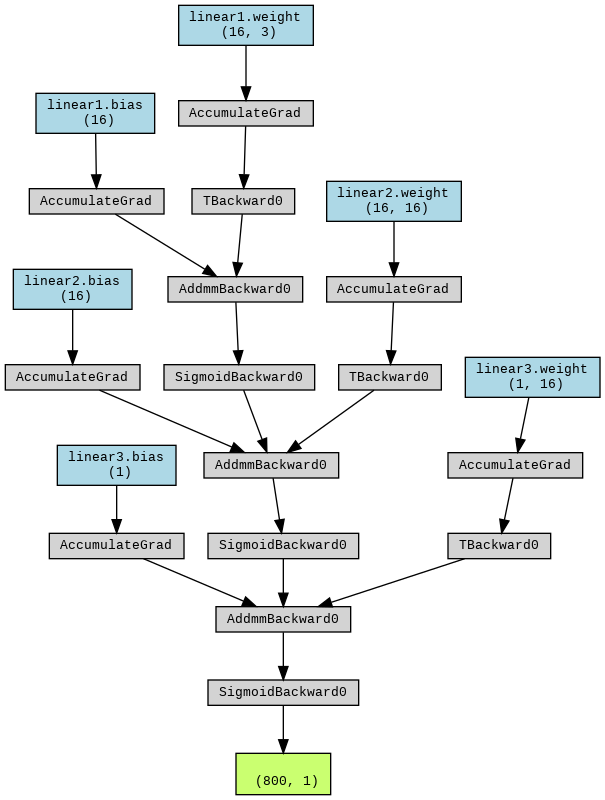

In [17]:
from torchviz import make_dot

model = MLPBinaryClassifier(input_size=num_features, hidden_size=hidden_size)
y_pred = model(x_train) # Pass in training set

dot = make_dot(y_pred, params=dict(model.named_parameters()))  # Generate the graph
dot.render("model_graph", format="png")  # Save the graph as a PNG file

from IPython.display import Image
Image(filename="model_graph.png")

### 3. Train the Model

Now that the architecture is ready, we can start training the model on the dataset by the following steps:
1. Create a model using the architecture class
2. Define a loss function and an optimizer
3. Start a loop for training, where each loop is an epoch
4. In each epoch, feed the input forward, calculate the loss, and implement back-propagation using the loss

In [18]:
import torch.optim as optim
import torchmetrics

hidden_size = 16
model = MLPBinaryClassifier(input_size=num_features, hidden_size=hidden_size)

# Define loss function and optimizer
loss_function = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.5)

# Start training
num_epochs = 1000
epochs = [] # x axis for histry
train_losses = [] # loss histry
test_losses = [] # loss histry
for epoch in range(num_epochs):

    # Feed-forward and get loss
    predictions = model(x_train) # acquire output value (prediction)
    train_loss = loss_function(predictions, y_train) # error between prediction and ground truth

    # Similarly, calculate test loss (optional)
    test_predictions = model(x_test)
    test_loss = loss_function(test_predictions, y_test)

    # Gradient descent
    optimizer.zero_grad()
    train_loss.backward() # backpropagation
    optimizer.step() # update parameters

    # Get loss values for printing
    train_loss = train_loss.item()
    test_loss = test_loss.item()

    # Print the losses periodically
    if epoch % 200 == 199:
        print('Epoch {}/{}, train loss: {:.4f}, test loss: {:.4f}'.format(epoch+1, num_epochs, train_loss, test_loss))

    # Save loss and accuracy
    epochs.append(epoch)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

Epoch 200/1000, train loss: 0.2439, test loss: 0.2440
Epoch 400/1000, train loss: 0.2232, test loss: 0.2224
Epoch 600/1000, train loss: 0.1417, test loss: 0.1403
Epoch 800/1000, train loss: 0.0690, test loss: 0.0682
Epoch 1000/1000, train loss: 0.0443, test loss: 0.0431


**What is the test loss for?**

The back-propagation update, `train_loss.backward()`, only involves the loss of the **training set**. This means that the **test set does not effect** the model parameters at all during training. Therefore, calculating the loss of the test set is optional. However, tracking the loss of the test set can help us understand if the test set is converging when the train set is converging. In the next step, we will learn how to use visualization tools to make our lives easier when tracking these values.

#### Loss Curve Visualization

A standard way to monitor the training is to **plot the loss curve**. In theory, loss will drop over training epochs, and we could observe that through the printed information. However, a more intuitive approach is to visualize those values with a curve. In this section, we will learn to implement the loss plot using the library, `matplotlib`.

Similar to the plotting methods we learned in Programming Tutorial 1, we can use `plt.plot()` to visualize a line. In this case, the input `epochs` will be the x values, and the input `losses` will be the y values for the line.

Let's create a function that can visualize **multiple curves** in the same figure. This is useful when there are multiple sets of data (e.g., train, validation, test).

In [19]:
import matplotlib.pyplot as plt

def loss_plot(epochs, losses_list, loss_names):
  plt.figure(figsize=(8, 3))

  # visualize every curve
  for losses, loss_name in zip(losses_list, loss_names):
    plt.plot(epochs, losses, label=loss_name)

  # set up labels
  plt.title('Binary Classification Model - Loss Plot')
  plt.xlabel('Training Epoch')
  plt.ylabel('Loss Value')
  plt.legend()
  plt.show()

In this example, we only have two sets, `train` and `test`.

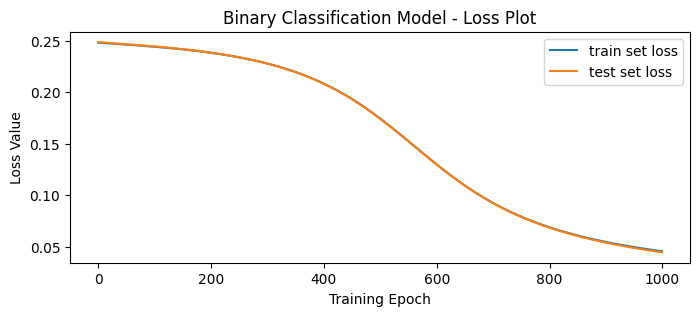

In [12]:
losses_list = [train_losses, test_losses]
loss_names = ['train set loss', 'test set loss']
loss_plot(epochs, losses_list, loss_names)

In the figure, we can easily spot that the losses for both train and test set drop beautifully over training epochs!

### 4. Model Evaluation


Now that the model has finished training, we can evaluate its performance using the evaluation metric(s). Turn on the evaluation mode for the model by `model.eval()`.

Let's see this model's performance on the test set:

In [13]:
# Define evaluation metric
accuracy_metric = torchmetrics.classification.BinaryAccuracy()

model.eval() # evaluation mode

# train
y_pred = model(x_train) # pass train input into the trained model
train_accuracy = accuracy_metric(y_pred, y_train)
print('Train set score (accuracy in %): {}'.format(train_accuracy*100))

# test
y_pred = model(x_test) # pass test input into the trained model
test_accuracy = accuracy_metric(y_pred, y_test)
print('Test set score (accuracy in %): {}'.format(test_accuracy*100))

Train set score (accuracy in %): 98.875
Test set score (accuracy in %): 99.5


## Review

It is common to feel overwhelmed by all the steps if this is your first time using PyTorch to train a model. Let's review all the steps below and get familiar with this library!

**[Dataset Preparation]**
- Generate a dataset with `x` (input) and `y` (output).
- Split your dataset into `train` and `test` sets.

**[Model Structure]**
- Build the model from the base class `nn.Module`
- In the model class, define layers including linear layers such as `nn.Linear` and activation layers such as `nn.Sigmoid`
- In the model's `forward` function, define the feed-forward mechanism by passing the tensor from layer to layer

**[Training]**
- Use an evaluation metric such as `torchmetrics.classification.BinaryAccuracy` to evaluate the model performace
- Select an optimizer such as `optim.SGD` and set up proper hyperparameters
- Select a loss function such as `nn.BCELoss()` for training
- Pass the input into the model such as `predictions = model(x_train)`
- Calculate the loss between prediction and ground truth such as `loss = loss_function(predictions, y_train)`

**[Evaluation]**
- To evaluate the model, set `model.eval()` and `torch.no_grad()`
- Pass the test set into the model for prediction such as `y_pred = model(x_test)`
- Acquire the score by applying the defined metric

**[Visualization]**
- To visualize the curves, use `matplotlib.pyplot.plot()`

You can try the following practices:
1. Create a new dataset with a different setup. For instance,
    ```
    num_samples = 500
    num_features = 2
    x = torch.rand(num_samples, num_features) # Generate random x samples
    y = (x[:,0] > 0.5).float().unsqueeze(1)  # Binary labels
    ```
    Normalize and split the dataset into train and test.

2. Build a binary classification model with 5 linear layers and `hidden_size=128`
3. Train this new model with your new dataset and plot the curves. Does the model converge?
4. Tweak the settings number of layers and hidden size. What setup would facilitate the model to converge faster?

In [58]:
import torch
from torch.utils.data import random_split, TensorDataset, DataLoader

num_samples = 10000
num_features = 2
x = torch.rand(num_samples, num_features) # Generate random x samples
y = (x[:,0] > 0.5).float().unsqueeze(1)  # Binary labels

# Normalize the data
xmean = x.mean(dim=0)
xstd = x.std(dim=0)
x_norm = (x - xmean) / (xstd + 1e-8)      # Avoid division by zero
print("Original features:\n", x[:5])
print("Normalized features:\n", x_norm[:5])

# Split the data
batch_size = 500
train_pct = 0.8
test_pct = 1 - train_pct
dataset = TensorDataset(x, y)   # Combine x,y to retain labels when using random_split
train_dataset, test_dataset = random_split(dataset, [train_pct, test_pct], torch.Generator().manual_seed(42)) # Use random_split to shuffle the data

# Generate mini-batches for SGD
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
)

Original features:
 tensor([[0.4270, 0.9739],
        [0.3471, 0.3376],
        [0.6306, 0.8614],
        [0.3756, 0.8991],
        [0.0187, 0.2524]])
Normalized features:
 tensor([[-0.2646,  1.6450],
        [-0.5426, -0.5651],
        [ 0.4432,  1.2540],
        [-0.4433,  1.3851],
        [-1.6845, -0.8614]])


In [60]:
# Build 5-layer binary classifier
import torch.nn as nn

class MLPBinaryClassifier(nn.Module):
  def __init__(self, input_size, hidden_size = 128):
    super(MLPBinaryClassifier, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size

    # Define all layers in the model
    # layer 1
    self.linear1 = nn.Linear(self.input_size, hidden_size)
    self.activation1 = nn.Sigmoid()
    # layer 2
    self.linear2 = nn.Linear(hidden_size, hidden_size)
    self.activation2 = nn.Sigmoid()
    # layer 3
    self.linear3 = nn.Linear(hidden_size, hidden_size)
    self.activation3 = nn.Sigmoid()
    # layer 4
    self.linear4 = nn.Linear(hidden_size, hidden_size)
    self.activation4 = nn.Sigmoid()
    # layer 5
    self.linear5 = nn.Linear(hidden_size, 1)
    self.activation5 = nn.Sigmoid()

  def forward(self, x):
    # Build the feed forward structure
    linear1 = self.linear1(x)
    act1 = self.activation1(linear1)
    linear2 = self.linear2(act1)
    act2 = self.activation2(linear2)
    linear3 = self.linear3(act2)
    act3 = self.activation3(linear3)
    linear4 = self.linear4(act3)
    act4 = self.activation4(linear4)
    linear5 = self.linear5(act4)
    output = self.activation5(linear5)
    return output

In [61]:
import torch.optim as optim

# Create an instance of the model, using the dimension of x_norm for the input size
model = MLPBinaryClassifier(input_size = x_norm.shape[1])

# Define loss function and optimizer
loss_function = nn.BCELoss()
optimizer = optim.SGD(params=model.parameters(), lr=0.1)

# Train the new model
N_epochs = 10000
epochs = []
train_losses = []
for epoch in range(N_epochs):
  # Unpack the DataLoader
  for batch_num, (x_batch, y_batch) in enumerate(train_loader):
    # Compute forward pass
    y_pred = model.forward(x_batch)

    # Compute loss
    train_loss = loss_function(y_pred, y_batch)

    # Backpropagation
    optimizer.zero_grad()   # Don't forget to zero out the gradients!
    train_loss.backward()

    # Update model parameters
    optimizer.step()

  # Save results
  epochs.append(epoch)
  train_losses.append(train_loss.item())

  if epoch % 100 == 99:
    print('Epoch {}/{} \t  train loss: {:4f}'.format(epoch + 1, N_epochs, train_loss))
    print("--------------------------------")



Epoch 100/10000 	  train loss: 0.680892
--------------------------------
Epoch 200/10000 	  train loss: 0.680130
--------------------------------
Epoch 300/10000 	  train loss: 0.675254
--------------------------------
Epoch 400/10000 	  train loss: 0.669288
--------------------------------
Epoch 500/10000 	  train loss: 0.664279
--------------------------------
Epoch 600/10000 	  train loss: 0.660480
--------------------------------
Epoch 700/10000 	  train loss: 0.657671
--------------------------------
Epoch 800/10000 	  train loss: 0.655596
--------------------------------
Epoch 900/10000 	  train loss: 0.653898
--------------------------------
Epoch 1000/10000 	  train loss: 0.607355
--------------------------------
Epoch 1100/10000 	  train loss: 0.000031
--------------------------------
Epoch 1200/10000 	  train loss: 0.000000
--------------------------------
Epoch 1300/10000 	  train loss: 0.000000
--------------------------------
Epoch 1400/10000 	  train loss: 0.000000
------

KeyboardInterrupt: 

In [ ]:
# Evaluate model performance on test data
model.eval()


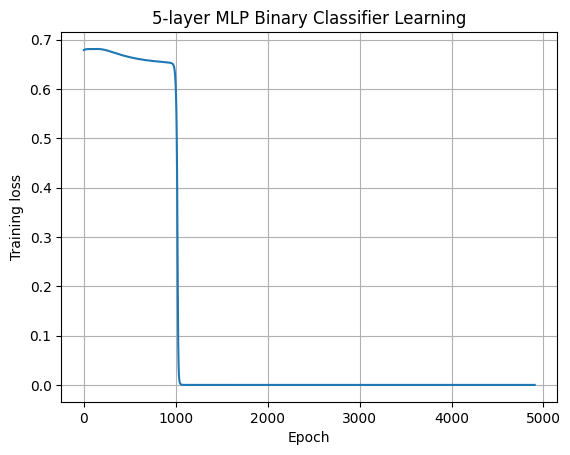

In [62]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epochs, train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("5-layer MLP Binary Classifier Learning")
plt.grid()
plt.show()

For any questions and discussions regarding this tutorial, attend [TA office hours](https://docs.google.com/spreadsheets/d/1abWD9DJqjEGrCdr8VbZ3aiOhx4vpT1y0-LOoLWgPwZM/edit?usp=sharing) or create a post on [Piazza](https://piazza.com/colorado/spring2026/csci49225922/home) :) See you in the next tutorial!

\- Everley